# **Redes Neuronales Convolucionales**
### Actividad grupal

---

En esta actividad se trabajará con Redes Neuronales Convolucionales (Convolutional Neural Networks, CNN) para resolver un problema de clasificación de imágenes. En particular, se utilizará un conjunto de imágenes de mascotas, enfocándose en la clasificación de perros y gatos.

Dado que las CNN profundas son modelos computacionalmente demandantes, se recomienda realizar la práctica en Google Colaboratory, aprovechando el soporte para unidades de procesamiento gráfico (GPU). En el siguiente enlace se describe el procedimiento para habilitar una GPU en Colab:  
[Guía para activar GPU en Google Colab](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d).

El conjunto de datos a utilizar es el **Oxford-IIIT Pet Dataset**, el cual contiene imágenes de distintas razas de perros y gatos. Su sitio oficial es:  
[Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/)

Este dataset es considerablemente más complejo que otros utilizados previamente, como Fashion MNIST, ya que:
- Incluye múltiples clases (razas),
- Presenta variaciones significativas en escala, pose e iluminación,
- Contiene imágenes con diferentes fondos y encuadres.

El conjunto de datos puede integrarse fácilmente a flujos de trabajo basados en frameworks de aprendizaje profundo como [Tensorflow](https://www.tensorflow.org/datasets/catalog/oxford_iiit_pet) y [PyTorch](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.OxfordIIITPet.html), ya sea mediante utilidades propias de cada framework o mediante descarga directa desde el sitio oficial.

Antes de iniciar el desarrollo del modelo, se recomienda descargar el dataset, explorar visualmente las imágenes y analizar su estructura, con el fin de comprender mejor los retos asociados al problema de clasificación.

## Librerías

In [28]:
import cv2
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
# Libreria para el dataset
import tensorflow_datasets as tfds

In [29]:
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from keras.models import Sequential
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import time
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import tensorflow as tf
import pandas as pd
import seaborn as sns


## Dataset

El dataset se encuentra la librería ***tfds***. En caso de no tener la líbrería instalarla mediante
```
# !pip install tensorflow-datasets
```
Las imágenes se descargan a través del método *load*, que tiene los siguientes parámetros:
* **split** indica la división del dataset, por ejemplo: "train" o ["train", "test"], ...
* **data_dir** ubicación donde se almacenan los datos, por dafault es ~/
* **with_info** devuelve los metadatos del dataset (tfds.core.DatasetInfo). Por default es *True*
* **download** deshabilita la descarga del dataset. Por default es False
* **as_supervised** descarga el dataset con su salida, variable y.

In [30]:
split_data, info = tfds.load(
    'oxford_iiit_pet',
     data_dir = '../datasets/oxford_iiit_pet',
    split=[
        'train[:80%]',     # entrenamiento
        'train[80%:90%]', # validación
        'train[90%:]'],   # prueba
    with_info = True,
    as_supervised=True
)


In [31]:
# Las imágenes se estandarizan al tamaño 160x160
IMG_SIZE = 160

El manejo de los datos del conjunto se realiza mediante la **API tf.data**, una herramienta de *TensorFlow* diseñada para construir *pipelines* de entrada de datos eficientes y escalables. Esta API es especialmente útil cuando se trabaja con conjuntos de datos de gran tamaño, ya que permite cargar y procesar la información en lotes pequeños (*batches*), optimizando el uso de recursos y mejorando el rendimiento durante el entrenamiento.

Cada conjunto de datos en **tf.data** se representa como un objeto de tipo `tf.data.Dataset`, el cual puede contener elementos en forma de tuplas o diccionarios de tensores (por ejemplo, `tf.float32`, `tf.int32`, `tf.string`). Esta estructura garantiza compatibilidad total con *TensorFlow* y facilita un procesamiento eficiente, ya que los datos se consumen de manera incremental durante el entrenamiento, reduciendo la necesidad de cargar todo el dataset en memoria al mismo tiempo.

### **Operaciones comunes en tf.data**

Las operaciones de `tf.data` pueden encadenarse para construir *pipelines* de procesamiento flexibles y eficientes. Algunas de las más utilizadas son:

* **map**: Aplica una función personalizada a cada elemento del `Dataset` (por ejemplo, normalización de imágenes o aumento de datos).
* **batch**: Agrupa los elementos en lotes de un tamaño especificado, lo que permite el entrenamiento por mini-lotes.
* **shuffle**: Mezcla aleatoriamente los elementos del `Dataset` utilizando un parámetro `buffer_size`. Un valor grande favorece una mejor aleatorización, especialmente en conjuntos de datos extensos.
* **repeat**: Repite el conjunto de datos un número determinado de veces, útil para controlar el número de épocas durante el entrenamiento.
* **prefetch**: Permite preparar los siguientes lotes mientras el modelo se encuentra entrenando, mejorando la utilización de recursos de CPU y GPU.

Para profundizar en el uso y configuración de estos métodos, se recomienda consultar la documentación oficial de [tf.data](https://www.tensorflow.org/guide/data).

In [32]:
(train_ds, val_ds, test_ds) = split_data

## Ejercicio

Utilizando ***Convolutional Neural Networks*** (CNN) implementadas con Keras, entrenar un clasificador capaz de reconocer razas de perros y gatos en imágenes, alcanzando una accuracy en el conjunto de **test** de al menos **85%**. Es indispensable que el **mejor modelo seleccionado no presente evidencias de overfitting ni de underfitting**.

El desarrollo de la actividad debe apoyarse en un **proceso experimental riguroso**, documentado mediante un **informe técnico**, en el cual se analicen de manera comparativa las distintas estrategias exploradas y se justifiquen las decisiones adoptadas con base en los resultados obtenidos.

A continuación, se detallan los aspectos que deben ser abordados en el informe:
* **Análisis exploratorio de los datos utilizados**, considerando la distribución de clases, el tamaño del dataset, ejemplos representativos de las imágenes y la identificación de posibles desbalances.
* **Diseño y evaluación de al menos cuatro modelos**. Se espera que al menos uno de ellos corresponda a una arquitectura propuesta por los estudiantes. Adicionalmente, pueden emplearse modelos preentrenados mediante *transfer learning* o *fine-tuning*.
* **Análisis de resultados**, incluyendo métricas de *precision* y *recall* por clase y/o el uso de una matriz de confusión, con el fin de identificar qué clases presentan mejor o peor desempeño.
* **Análisis visual de los errores del modelo**, discutiendo qué tipos de imágenes o qué razas generan mayor confusión.
* **Comparación del desempeño de modelos basados en CNN frente a un modelo Fully Connected** (quinto modelo), considerando las imágenes aplanadas como entrada.
* **Entrenamiento y comparación de distintas arquitecturas CNN**, discutiendo aspectos como la profundidad de la red, hiperparámetros, optimizador, funciones de activación, uso de técnicas de regularización y batch normalization, entre otros.
* **Empleo de técnicas de data augmentation** y análisis de su impacto en el desempeño y la capacidad de generalización del modelo.

---
### **Notas importantes**

* Los conjuntos de **training** y **validation** deben emplearse durante el entrenamiento y ajuste de los modelos. El conjunto de **test** debe utilizarse **exclusivamente para la evaluación final del desempeño**.
* Evitar el reentrenamiento de los modelos, salvar el mejor modelo de cada modelo empleado, para que en caso de ser necesario se realicen las predicciones sin necesidad de emplear GPU.
* Es obligatorio verificar que el modelo no presente **overfitting**, apoyándose en el análisis de las curvas de entrenamiento y validación.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos evaluados. No obstante, se recomienda conservar las gráficas de entrenamiento para sustentar el análisis en el informe. **De manera obligatoria, debe mostrarse el entrenamiento completo y la evaluación sobre el conjunto de test del mejor modelo obtenido**.
* Las imágenes **no se encuentran normalizadas**, por lo que es necesario aplicar un proceso de normalización previo al entrenamiento del modelo.

---
### **Notas adicionales**

* Con el fin de **optimizar el uso de recursos computacionales**, se debe **evitar el reentrenamiento innecesario de los modelos**. Para cada arquitectura evaluada, es obligatorio **guardar el mejor modelo obtenido**, utilizando como criterio su desempeño sobre el conjunto de validación.
* En caso de requerir nuevas predicciones, análisis de errores o comparaciones adicionales, estas deberán realizarse **cargando los modelos previamente almacenados**, sin necesidad de volver a entrenarlos ni de emplear GPU.
* Para garantizar la **reproducibilidad de los experimentos**, se recomienda fijar de manera consistente las semillas aleatorias (*random seeds*) asociadas al entrenamiento, así como documentar los hiperparámetros, configuraciones del optimizador y criterios de parada utilizados en cada modelo.
* La **trazabilidad experimental** debe quedar reflejada en el notebook y en el informe técnico, de modo que sea posible identificar claramente qué configuraciones dieron lugar a cada resultado reportado. Esto incluye la asociación explícita entre modelos entrenados, métricas obtenidas, curvas de entrenamiento y conclusiones derivadas.

### Análisis Exploratorio de Datos (EDA)

#### Resumen del dataset

In [33]:
for name, ds in [('train', train_ds), ('val', val_ds), ('test', test_ds)]:
    print(name, ds.cardinality().numpy())

print('clases:', info.features['label'].num_classes)
print('nombres:', info.features['label'].names)   # 37 razas
print('especies:', info.features['species'].names) # Cat, Dog

train 2944
val 368
test 368
clases: 37
nombres: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair', 'chihuahua', 'Egyptian_Mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'Maine_Coon', 'miniature_pinscher', 'newfoundland', 'Persian', 'pomeranian', 'pug', 'Ragdoll', 'Russian_Blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'Siamese', 'Sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']
especies: ['Cat', 'Dog']


#### Distribución de clases por split

Balance por clase (train):
  mínimo: 70 | máximo: 87 | media: 79.6
  ratio máx/mín: 1.24
  menos frecuente: Sphynx (70)
  más frecuente  : american_pit_bull_terrier (87)


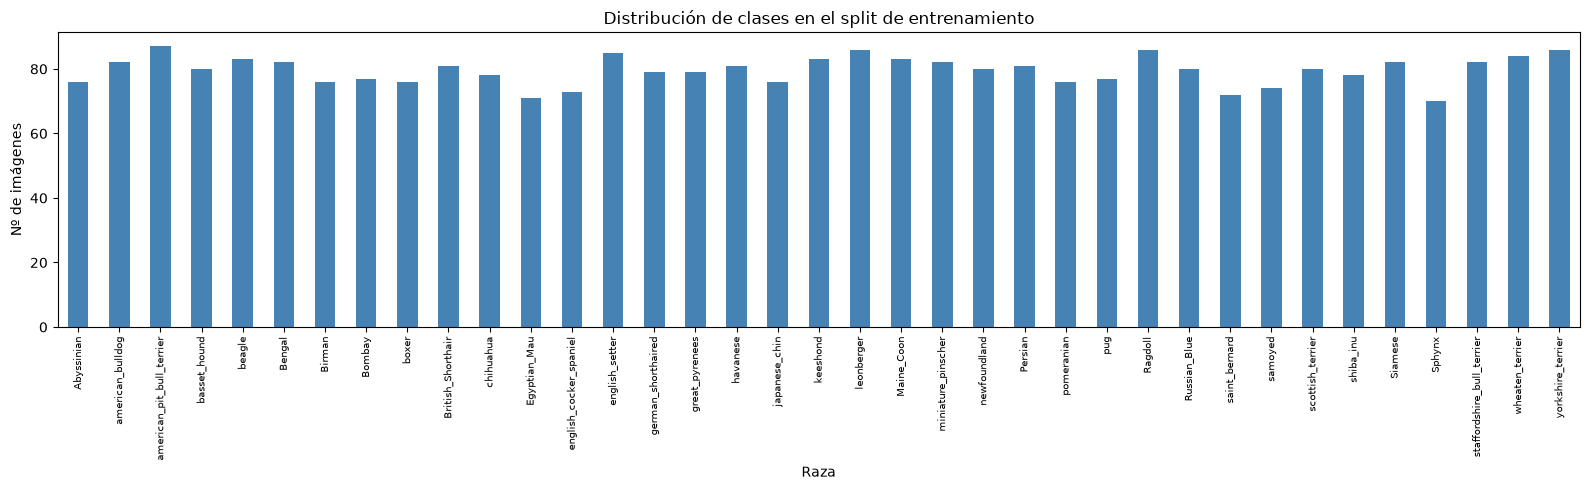

In [34]:
nombres = np.array(info.features['label'].names)

def contar_clases(ds):
    etiquetas = np.array([int(y) for _, y in ds])
    return pd.Series(
        np.bincount(etiquetas, minlength=info.features['label'].num_classes),
        index=nombres,
    )

conteo_train = contar_clases(train_ds)
conteo_val   = contar_clases(val_ds)
conteo_test  = contar_clases(test_ds)

df_conteo = pd.DataFrame({'train': conteo_train, 'val': conteo_val, 'test': conteo_test})
df_conteo['total'] = df_conteo.sum(axis=1)
df_conteo

print('Balance por clase (train):')
print(f'  mínimo: {conteo_train.min()} | máximo: {conteo_train.max()} | media: {conteo_train.mean():.1f}')
print(f'  ratio máx/mín: {conteo_train.max() / conteo_train.min():.2f}')
print(f'  menos frecuente: {conteo_train.idxmin()} ({conteo_train.min()})')
print(f'  más frecuente  : {conteo_train.idxmax()} ({conteo_train.max()})')

fig, ax = plt.subplots(figsize=(16, 5))
df_conteo['train'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribución de clases en el split de entrenamiento')
ax.set_xlabel('Raza')
ax.set_ylabel('Nº de imágenes')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()


#### Distribución de especies (gato vs perro)


Dog    2492
Cat    1188
Name: count, dtype: int64


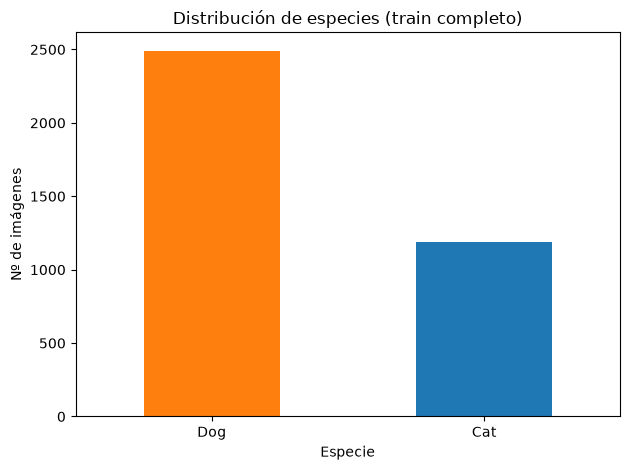

In [35]:
ds_especie = tfds.load(
    'oxford_iiit_pet',
    data_dir='../datasets/oxford_iiit_pet',
    split='train',
    as_supervised=False,
    decoders={'image': tfds.decode.SkipDecoding(), 'segmentation_mask': tfds.decode.SkipDecoding()},
)

especies = np.array([int(x['species']) for x in ds_especie])
conteo_especie = pd.Series(especies).map(dict(enumerate(info.features['species'].names))).value_counts()

print(conteo_especie)

conteo_especie.plot(kind='bar', color=['tab:orange', 'tab:blue'], rot=0)
plt.title('Distribución de especies (train completo)')
plt.xlabel('Especie')
plt.ylabel('Nº de imágenes')
plt.tight_layout()
plt.show()


#### Comparación de la distribución entre splits


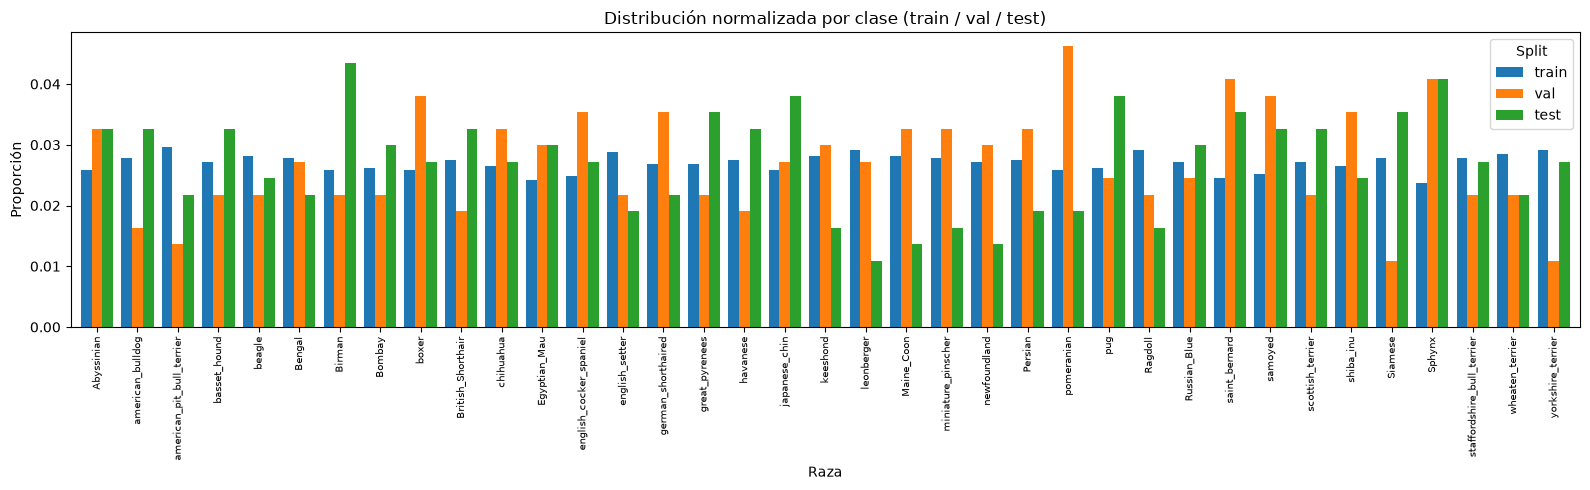

In [36]:
df_norm = df_conteo[['train', 'val', 'test']].div(df_conteo[['train', 'val', 'test']].sum(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(16, 5))
df_norm.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Distribución normalizada por clase (train / val / test)')
ax.set_xlabel('Raza')
ax.set_ylabel('Proporción')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.legend(title='Split')
plt.tight_layout()
plt.show()


#### Visualización de imágenes


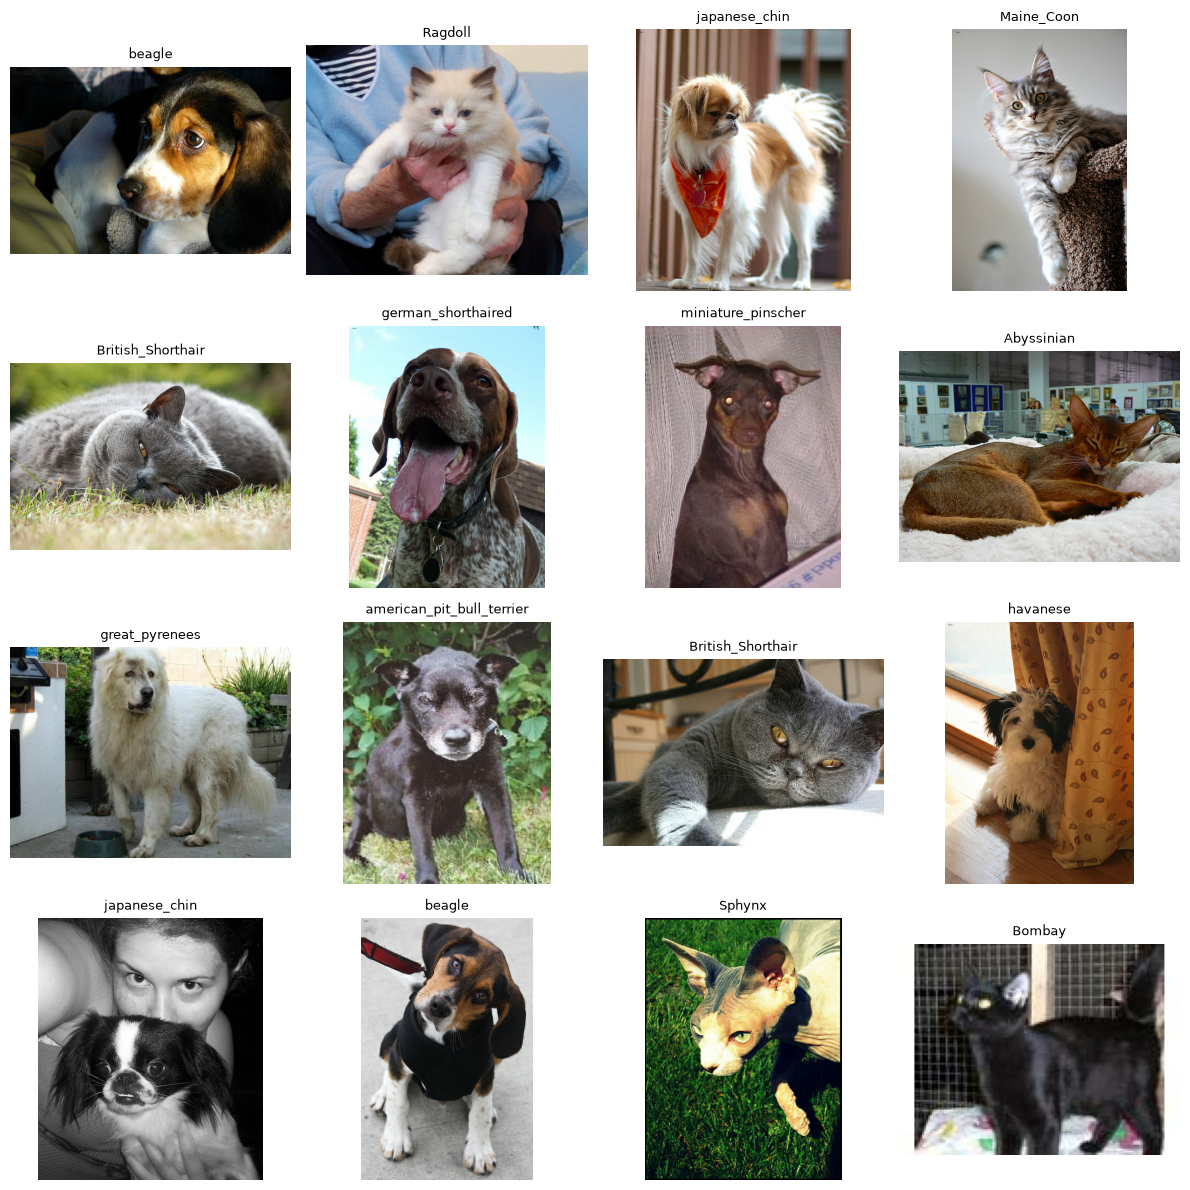

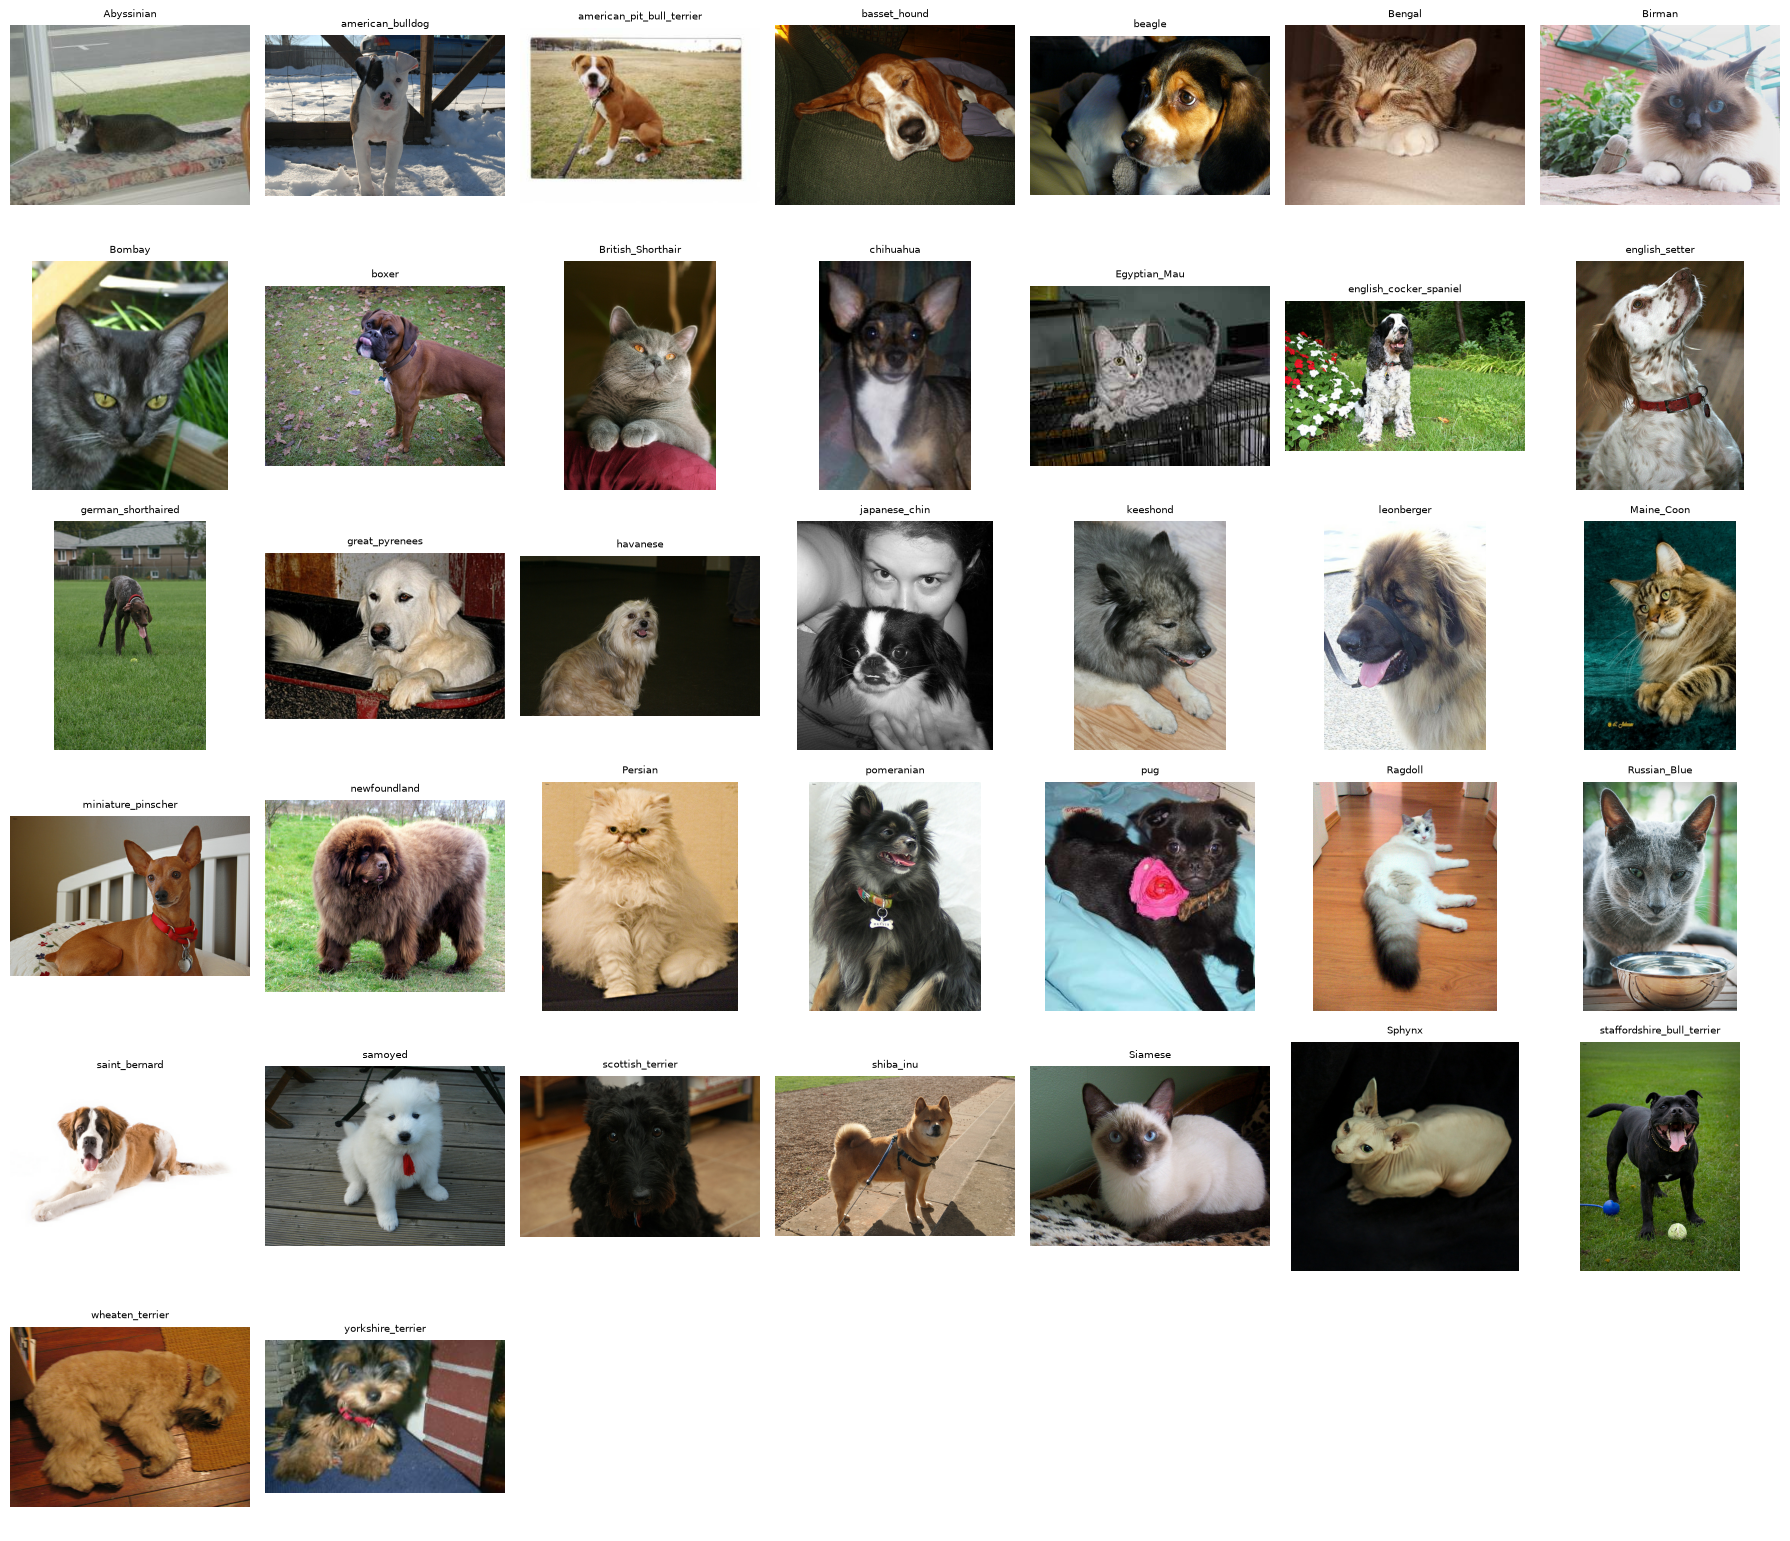

In [37]:
n_cols, n_rows = 4, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 12))

for ax, (imagen, etiqueta) in zip(axes.ravel(), train_ds.shuffle(1000).take(n_rows * n_cols)):
    ax.imshow(imagen.numpy())
    ax.set_title(nombres[int(etiqueta)], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

num_clases = info.features['label'].num_classes
ejemplos = {}
for imagen, etiqueta in train_ds:
    c = int(etiqueta)
    if c not in ejemplos:
        ejemplos[c] = imagen
    if len(ejemplos) == num_clases:
        break

cols = 7
rows = int(np.ceil(num_clases / cols))
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 2.6))
for i in range(num_clases):
    ax = axes[i // cols, i % cols]
    ax.imshow(ejemplos[i].numpy())
    ax.set_title(nombres[i], fontsize=7)
    ax.axis('off')
for j in range(num_clases, rows * cols):
    axes[j // cols, j % cols].axis('off')
plt.tight_layout()
plt.show()


#### Análisis del tamaño de las imágenes


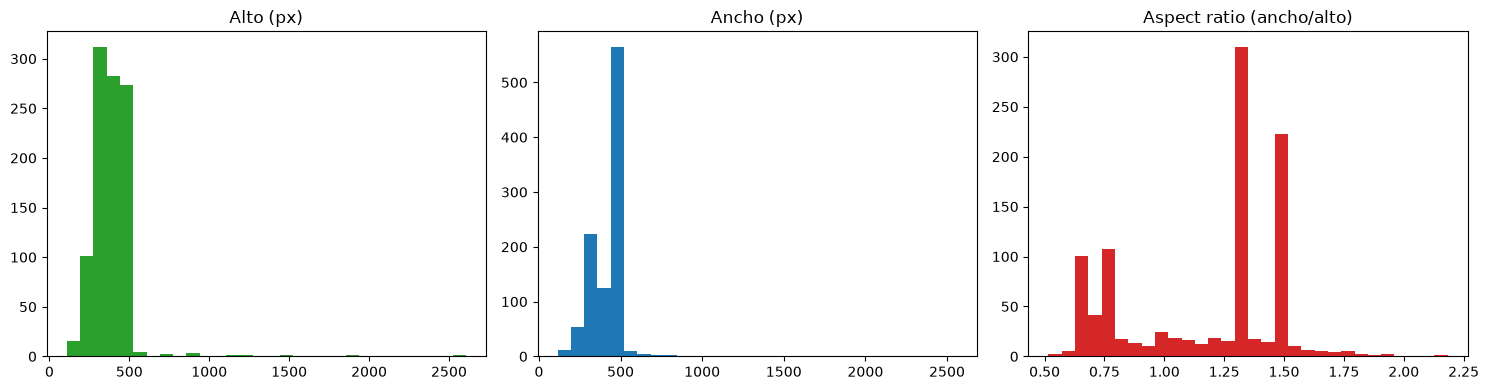

Alto  -> min 108, max 2606, media 385
Ancho -> min 114, max 2560, media 435
Tamaños distintos en la muestra: 307


In [38]:
altos, anchos = [], []
for imagen, _ in train_ds.take(1000):
    h, w, _ = imagen.shape.as_list()
    altos.append(h)
    anchos.append(w)

altos = np.array(altos)
anchos = np.array(anchos)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(altos, bins=30, color='tab:green')
axes[0].set_title('Alto (px)')
axes[1].hist(anchos, bins=30, color='tab:blue')
axes[1].set_title('Ancho (px)')
axes[2].hist(anchos / altos, bins=30, color='tab:red')
axes[2].set_title('Aspect ratio (ancho/alto)')
plt.tight_layout()
plt.show()

print(f'Alto  -> min {altos.min()}, max {altos.max()}, media {altos.mean():.0f}')
print(f'Ancho -> min {anchos.min()}, max {anchos.max()}, media {anchos.mean():.0f}')
print(f'Tamaños distintos en la muestra: {len(set(zip(altos, anchos)))}')


#### Conclusión del EDA


In [39]:
ratio = conteo_train.max() / conteo_train.min()
print('=' * 56)
print('VEREDICTO DE BALANCE (split de entrenamiento)')
print(f'  Rango: {conteo_train.min()} - {conteo_train.max()} imágenes por clase')
print(f'  Ratio máx/mín: {ratio:.2f}')
if ratio < 1.5:
    print('  => Dataset prácticamente balanceado: no requiere class_weight ni oversampling.')
else:
    print('  => Existe desbalance: considerar class_weight o data augmentation.')
print('=' * 56)


VEREDICTO DE BALANCE (split de entrenamiento)
  Rango: 70 - 87 imágenes por clase
  Ratio máx/mín: 1.24
  => Dataset prácticamente balanceado: no requiere class_weight ni oversampling.
